## Data Prepration

In [79]:
import pandas as pd
import numpy as np

data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [80]:
!curl -o data.csv $data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  620k  100  620k    0     0  1128k      0 --:--:-- --:--:-- --:--:-- 1127k


In [113]:
df = pd.read_csv('data.csv')

In [114]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [115]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [116]:
# df.columns = df.columns.str.lower().str.replace(' ', '_')

In [117]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [118]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_').str.replace('-', '_')

In [119]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front_wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front_wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front_wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front_wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front_wheel_drive,3,2580,7,304.0,4510,17.5,31.0


## EDA (Exploratory data analysis)

In [120]:
print(len(df))
print()

for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

10000

model_year
[2006 2008 1996 1989 1994]
50

origin
<StringArray>
['europe', 'asia', 'usa']
Length: 3, dtype: str
3

fuel_type
<StringArray>
['gasoline', 'diesel', 'hybrid']
Length: 3, dtype: str
3

drivetrain
<StringArray>
['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive']
Length: 3, dtype: str
3

num_doors
[4 5 3 2]
4

engine_displacement
[2180 2390 2320 2130 2580]
127

num_cylinders
[6 7 5 8 4]
5

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

acceleration
[ nan 17.3 18.7 17.5 18.8]
93

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

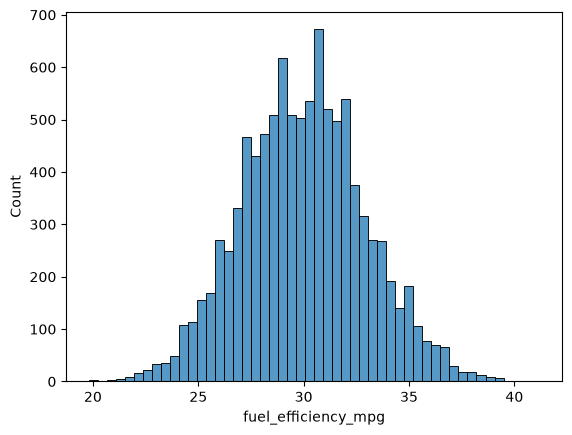

In [122]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

# sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 100000], bins=50)

In [123]:
# if data very big or skewed can use log

fuel_efficience_mpg_logs = np.log1p(df.fuel_efficiency_mpg)


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

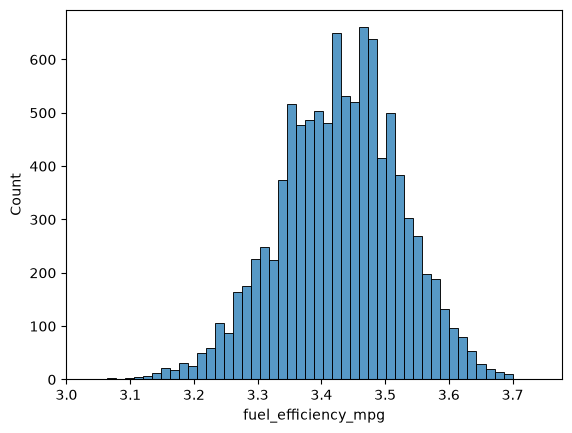

In [124]:
sns.histplot(fuel_efficience_mpg_logs, bins=50)

In [125]:
df.isnull().sum().values > 0

array([False, False, False, False, False, False, False,  True, False,
        True, False])

In [126]:
df.columns[df.isnull().sum().values > 0]

Index(['horsepower', 'acceleration'], dtype='str')

## Setting up validation framework

In [127]:
n = len(df)

n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train = n - n_val - n_test

print(n_val, n_test, n_train)

2000 2000 6000


In [128]:
idx = np.arange(n)

np.random.seed(2)
np.random.shuffle(idx)

In [129]:
# df_val = df.iloc[ : n_val]
# df_test = df.iloc[n_val + 1 : n_val + n_test]
# df_train = df.iloc[n_val + n_test + 1 : ]

#df_train = df[n_val + n_test + 1 : ] -> Only take labels, not the rows.


In [130]:
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train : n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [131]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [132]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Linear Regression

In [182]:
df_train.iloc[10]

model_year                          1987
origin                               usa
fuel_type                       gasoline
drivetrain             front_wheel_drive
num_doors                              2
engine_displacement                 1990
num_cylinders                          6
horsepower                         238.0
vehicle_weight                      4070
acceleration                        17.9
Name: 10, dtype: object

In [235]:
# xi = [model_year, horsepower, acceleration]
xi = [1987, 238, 17.9]
w0 = 7.17 # initial weight
w = [0.001, 0.01,0.04] # weight of each feature

In [236]:
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [237]:
prediction = linear_regression(xi)
prediction

12.252999999999998

In [238]:
yi = np.expm1(prediction)

print(yi)

209608.1740932432


### Linear regression vector form

In [239]:
def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [240]:
w_new = [w0] + w

In [241]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [242]:
pred = linear_regression(xi)
pred

12.252999999999998

In [243]:
yi = np.expm1(pred)

print(yi)

209608.1740932432


**Now for X:**

In [277]:
# xi = [model_year, horsepower, acceleration]
x1 = [2012, 237, 17.9]
x2 = [2008, 245, 18.2]
x10 = [1987, 238, 17.9]
X = [x1, x2, x10]
X = np.array(X)
X = np.c_[np.ones(len(X)), X]


w0 = 7.17
w = [0.001, 0.01,0.04]
w_new = [w0] + w

In [278]:
def linear_regression(X):
    return X.dot(w_new)

In [279]:
linear_regression(X)

array([12.268, 12.356, 12.253])

## Training a linear regression model

In [308]:
X = [
    [2012, 237, 17.9],
    [2008, 245, 18.2],
    [1987, 238, 17.9],
    [2012, 237, 17.9],
    [2008, 245, 18.2],
    [1987, 238, 17.9],
    [2012, 237, 17.9],
    [2008, 245, 18.2],
    [1987, 238, 17.9],
]

X = np.array(X)

y = [3.49650756, 3.49347266, 3.475067230228611, 3.49650756, 3.49347266, 3.475067230228611, 3.49650756, 3.49347266, 3.475067230228611]

In [ ]:
def train_linear_regression(X, y):
    ones = np. ones (X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [310]:
train_linear_regression(X, y)

(np.float64(-24.105047772727687), array([0.01078206, 0.00404163, 0.32279269]))

## Car price baseline model

In [377]:
df_train.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
dtype: object

In [378]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'num_cylinders', 'acceleration']

In [379]:
X_train = df_train[base].fillna(0).values

In [380]:
w0, w = train_linear_regression(X_train, y_train)

In [381]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

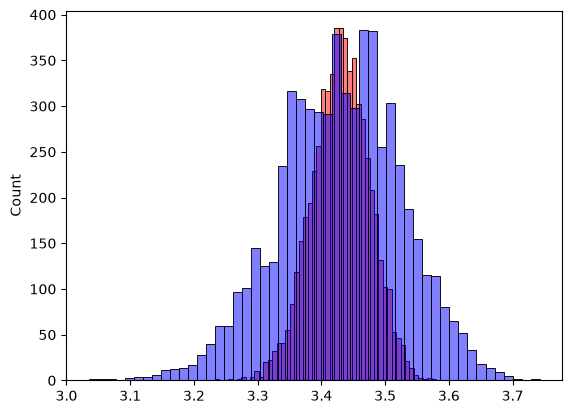

In [382]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

## RMSE

In [383]:
def rmse(y, y_pred) :
    se = (y - y_pred) ** 2
    mse = se.mean()

    return np.sqrt(mse)

In [384]:
rmse(y_train, y_pred)

np.float64(0.08462478930396106)

## Validating the model

In [385]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'num_cylinders', 'acceleration']

In [386]:
def prepare_X(df) :
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [387]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.08192548386145608)

## Simple feature engineering

In [436]:
df.model_year.max()

np.int64(2024)

In [437]:
def prepare_X(df) :
    df = df.copy()
    df['age'] = 2024 - df.model_year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [438]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.07001559297699933)

<Axes: ylabel='Count'>

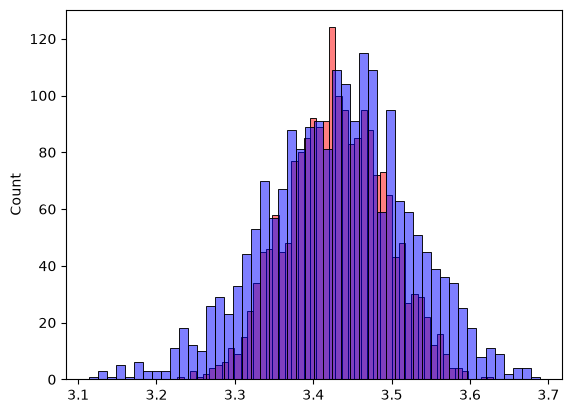

In [439]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## Categorial Variables

In [ ]:
# num_door_unique = df_train.num_doors.unique()

In [ ]:
# def prepare_X(df) :
#     df = df.copy()
#     df['age'] = 2024 - df.model_year
#     features = base + ['age']

#     for v in num_door_unique:
#         df['num_doors_%s' %v] = (df.num_doors == v).astype(int)
#         features.append('num_doors_%s' % v)

#     df_num = df[features]
#     df_num = df_num.fillna(0)
#     X = df_num.values
    
#     return X

In [ ]:
# X_train = prepare_X(df_train)
# w0, w = train_linear_regression(X_train, y_train)

# X_val = prepare_X(df_val)
# y_pred = w0 + X_val.dot(w)

# rmse(y_val, y_pred)

np.float64(11.867580307863884)

<Axes: ylabel='Count'>

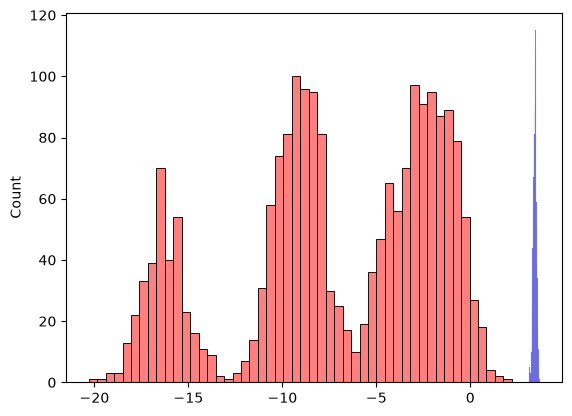

In [ ]:
# sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
# sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [453]:
df_train.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
dtype: object

In [462]:
categorical_variables = ['origin', 'fuel_type', 'drivetrain', 'num_doors']

In [463]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

categories

{'origin': ['usa', 'asia', 'europe'],
 'fuel_type': ['gasoline', 'diesel', 'hybrid'],
 'drivetrain': ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive'],
 'num_doors': [4, 3, 2, 5]}

In [464]:
def prepare_X(df) :
    df = df.copy()
    df['age'] = 2024 - df.model_year
    features = base + ['age']

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype(int)
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [465]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(37.610567879320065)

<Axes: ylabel='Count'>

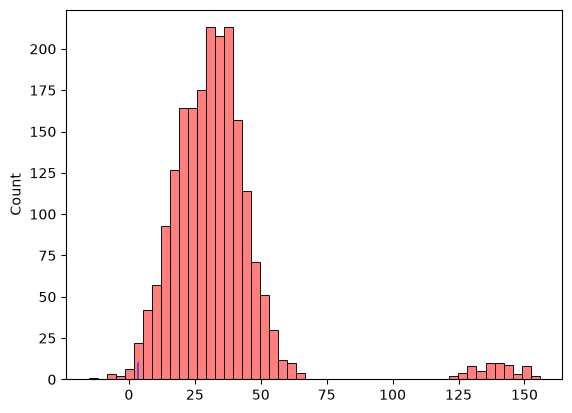

In [466]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## Regilarization

In [469]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000002, 1],
]

XTX = np.array(XTX)

In [471]:
np.linalg.inv(XTX)  ## Numbers become large

array([[-3.33333363e-01,  4.44444454e-01,  2.22222227e-01],
       [ 2.22222227e-01, -3.33333341e+06,  3.33333330e+06],
       [ 4.44444454e-01,  3.33333319e+06, -3.33333341e+06]])

In [476]:
# we can add number to diagonal

XTX = XTX + 0.01 * np.eye(3)

In [477]:
np.linalg.inv(XTX)

array([[ -0.33668909,   0.33501232,   0.33501567],
       [  0.33501567,  49.91615898, -50.08534189],
       [  0.33501232, -50.0853402 ,  49.91615898]])

In [479]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np. ones (X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [483]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, 0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.05374270021232429)

<Axes: ylabel='Count'>

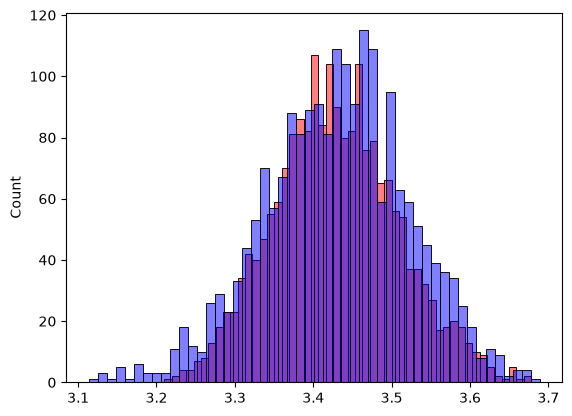

In [485]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## Tuning the model

In [491]:
mini = 10e9

for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10, 0.01]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    mini = min(score, mini)

    print(r, w0, score)

print("Best: ", mini)

0.0 1461772903533111.8 37.610567879320065
1e-05 2.0453144020315284 0.053743091492831734
0.0001 1.7889359399917124 0.0537430940660781
0.001 1.7910829868078113 0.053743055646967616
0.1 1.7859423533994219 0.05374202550215913
1 1.7410240769842718 0.0540066135574785
10 1.3918389462677556 0.07032535914489446
0.01 1.790562619937852 0.05374270021232429
Best:  0.05374202550215913


In [506]:
r = 0.1

In [497]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.05374202550215913)

## Using the model

In [502]:
df_full_train = pd.concat([df_train, df_val])

df_full_train = df_full_train.reset_index(drop=True)

In [503]:
df_full_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2013,usa,diesel,all_wheel_drive,2,2520,7,297.0,4510,17.8
1,2012,europe,gasoline,front_wheel_drive,2,1970,6,237.0,3990,17.9
2,2008,asia,gasoline,rear_wheel_drive,4,2250,6,245.0,4230,18.2
3,2021,usa,gasoline,all_wheel_drive,4,2120,6,227.0,4420,20.5
4,2003,europe,diesel,front_wheel_drive,5,2260,6,264.0,4090,16.9
...,...,...,...,...,...,...,...,...,...,...
7995,1997,usa,diesel,rear_wheel_drive,4,2340,6,283.0,4700,19.9
7996,1985,usa,gasoline,front_wheel_drive,4,2390,6,278.0,4250,18.8
7997,1999,europe,hybrid,all_wheel_drive,2,2310,6,244.0,4380,19.6
7998,1976,asia,gasoline,all_wheel_drive,5,2350,6,246.0,4370,20.4


In [504]:
X_full_train = prepare_X(df_full_train)

In [505]:
y_full_train = np.concatenate([y_train, y_val])

In [514]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r)

In [515]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

np.float64(0.05403907958776741)

In [521]:
car = df_test.iloc[20].to_dict()

In [523]:
df_small = pd.DataFrame([car])

X_small = prepare_X(df_small)

In [527]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]

In [528]:
np.expm1(y_pred)

np.float64(29.33256020823848)

In [530]:
np.expm1(y_test[20])

np.float64(29.5)